In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.shape

(918, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df_numeric = df.select_dtypes(["int64","float64"])

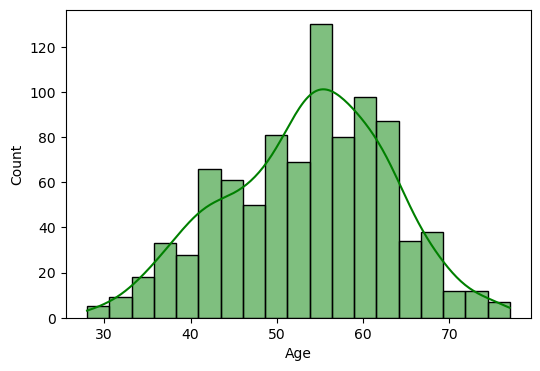

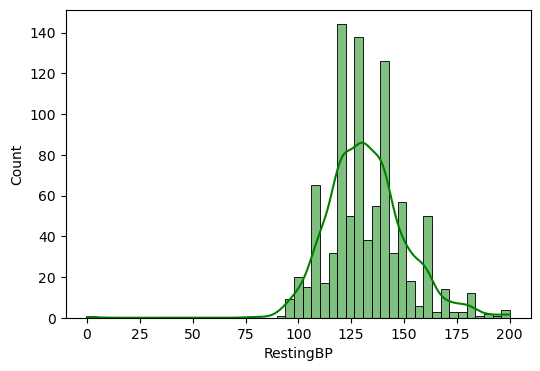

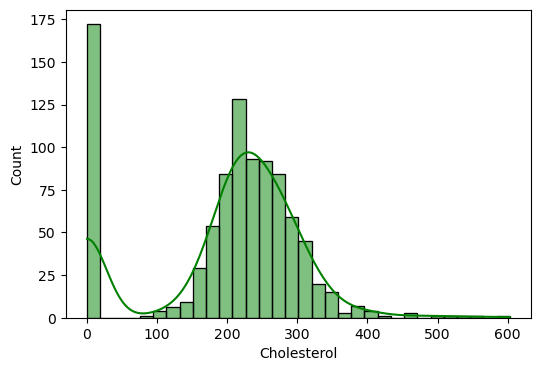

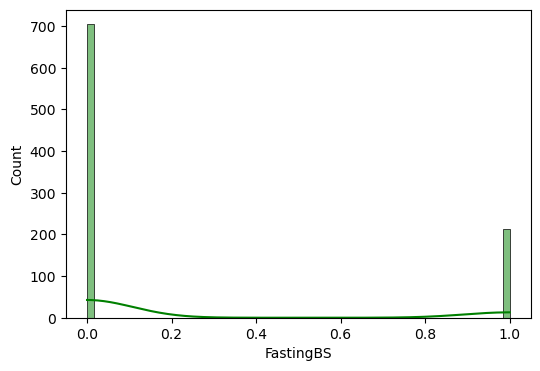

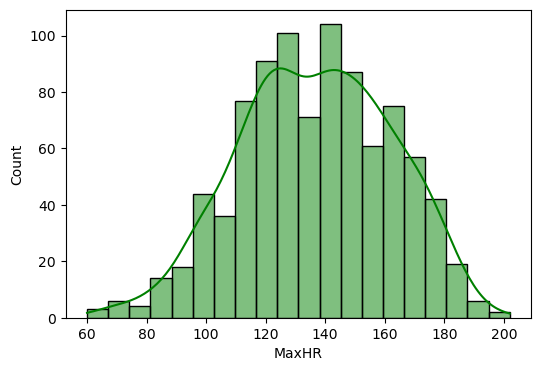

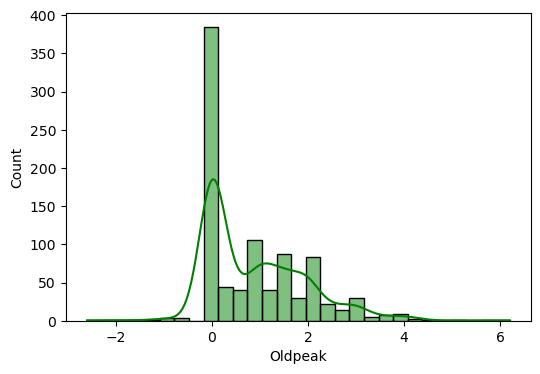

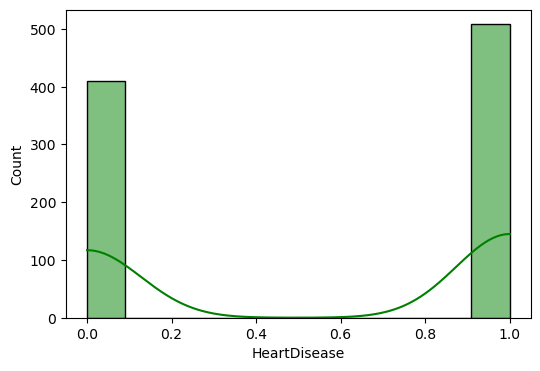

In [9]:
for col in df_numeric:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col], kde = True, color = "green")
    plt.show()

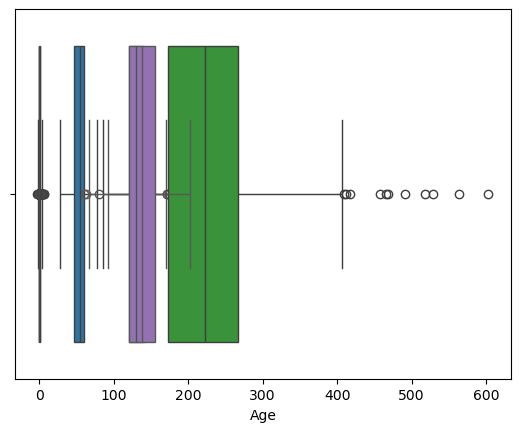

In [10]:
for col in df_numeric:
    if col != 'HeartDisease':
        sns.boxplot(x = df[col])
        plt.show

In [11]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

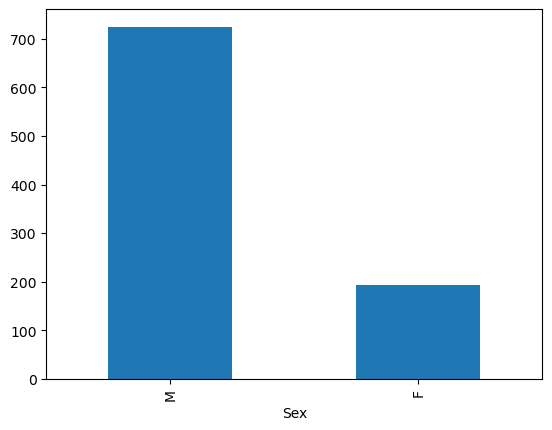

In [12]:
df["Sex"].value_counts().plot(kind = "bar")
plt.show()

In [13]:
df["ChestPainType"].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [14]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


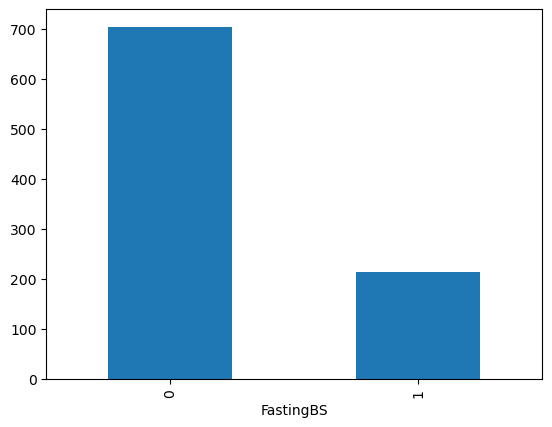

In [15]:
df["FastingBS"].value_counts().plot(kind = "bar")
plt.show()

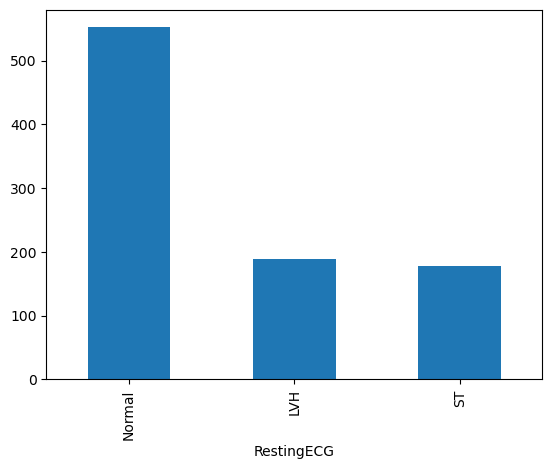

In [16]:
df["RestingECG"].value_counts().plot(kind = "bar")
plt.show()

In [17]:
df["ExerciseAngina"].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

In [18]:
df["Sex"] = df["Sex"].map({
    "M" : 0,
    "F" : 1
})

In [19]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [20]:
df.rename(columns={"Sex": "Gender"},inplace = True)

In [21]:
df.head()

,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [22]:
df["ChestPainType"].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [23]:
df_cleaned = df.copy()

In [24]:
df_cleaned = pd.get_dummies(df_cleaned, columns=["ChestPainType"], drop_first=True)



In [25]:
df_cleaned.head()

,Age,Gender,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,0,140,289,0,Normal,172,N,0.0,Up,0,True,False,False
1,49,1,160,180,0,Normal,156,N,1.0,Flat,1,False,True,False
2,37,0,130,283,0,ST,98,N,0.0,Up,0,True,False,False
3,48,1,138,214,0,Normal,108,Y,1.5,Flat,1,False,False,False
4,54,0,150,195,0,Normal,122,N,0.0,Up,0,False,True,False


In [26]:
df.head()

,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [27]:
df_cleaned.head()

,Age,Gender,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,0,140,289,0,Normal,172,N,0.0,Up,0,True,False,False
1,49,1,160,180,0,Normal,156,N,1.0,Flat,1,False,True,False
2,37,0,130,283,0,ST,98,N,0.0,Up,0,True,False,False
3,48,1,138,214,0,Normal,108,Y,1.5,Flat,1,False,False,False
4,54,0,150,195,0,Normal,122,N,0.0,Up,0,False,True,False


In [28]:
# df_cleaned.drop("ChestPainType", axis = 1, inplace = True)

In [29]:
df_cleaned.columns

Index(['Age', 'Gender', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG',
       'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA'],
      dtype='object')

In [30]:
df_cleaned["RestingECG"].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

In [31]:
df_cleaned = pd.get_dummies(df_cleaned, columns=["RestingECG"], drop_first= True)



In [32]:
df_cleaned.head()

,Age,Gender,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,0,140,289,0,172,N,0.0,Up,0,True,False,False,True,False
1,49,1,160,180,0,156,N,1.0,Flat,1,False,True,False,True,False
2,37,0,130,283,0,98,N,0.0,Up,0,True,False,False,False,True
3,48,1,138,214,0,108,Y,1.5,Flat,1,False,False,False,True,False
4,54,0,150,195,0,122,N,0.0,Up,0,False,True,False,True,False


In [33]:
# df_cleaned.drop("RestingECG", axis = 1, inplace = True)

In [34]:
df_cleaned.head()

,Age,Gender,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,0,140,289,0,172,N,0.0,Up,0,True,False,False,True,False
1,49,1,160,180,0,156,N,1.0,Flat,1,False,True,False,True,False
2,37,0,130,283,0,98,N,0.0,Up,0,True,False,False,False,True
3,48,1,138,214,0,108,Y,1.5,Flat,1,False,False,False,True,False
4,54,0,150,195,0,122,N,0.0,Up,0,False,True,False,True,False


In [35]:
df.head()

,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [36]:
df_cleaned["ST_Slope"].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

In [37]:
df_cleaned = pd.get_dummies(df_cleaned, columns=["ST_Slope"], drop_first= True)



In [38]:
df_cleaned.head()

,Age,Gender,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,N,0.0,0,True,False,False,True,False,False,True
1,49,1,160,180,0,156,N,1.0,1,False,True,False,True,False,True,False
2,37,0,130,283,0,98,N,0.0,0,True,False,False,False,True,False,True
3,48,1,138,214,0,108,Y,1.5,1,False,False,False,True,False,True,False
4,54,0,150,195,0,122,N,0.0,0,False,True,False,True,False,False,True


In [39]:
# df_cleaned.drop("ST_Slope", axis = 1, inplace = True)

In [40]:
df_cleaned.columns

Index(['Age', 'Gender', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal',
       'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [41]:
df.head()

,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [42]:
df["ChestPainType"].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [43]:
df_cleaned.head()

,Age,Gender,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,N,0.0,0,True,False,False,True,False,False,True
1,49,1,160,180,0,156,N,1.0,1,False,True,False,True,False,True,False
2,37,0,130,283,0,98,N,0.0,0,True,False,False,False,True,False,True
3,48,1,138,214,0,108,Y,1.5,1,False,False,False,True,False,True,False
4,54,0,150,195,0,122,N,0.0,0,False,True,False,True,False,False,True


In [44]:
df_cleaned.dtypes

Age                    int64
Gender                 int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
ExerciseAngina        object
Oldpeak              float64
HeartDisease           int64
ChestPainType_ATA       bool
ChestPainType_NAP       bool
ChestPainType_TA        bool
RestingECG_Normal       bool
RestingECG_ST           bool
ST_Slope_Flat           bool
ST_Slope_Up             bool
dtype: object

In [45]:
df_cleaned["ExerciseAngina"] = df_cleaned["ExerciseAngina"].map({
    "N" : 0,
    "Y" : 1
})

In [46]:
df_cleaned.dtypes

Age                    int64
Gender                 int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
ExerciseAngina         int64
Oldpeak              float64
HeartDisease           int64
ChestPainType_ATA       bool
ChestPainType_NAP       bool
ChestPainType_TA        bool
RestingECG_Normal       bool
RestingECG_ST           bool
ST_Slope_Flat           bool
ST_Slope_Up             bool
dtype: object

In [47]:
bool_col = df_cleaned.select_dtypes(include = ["bool"]).columns

In [48]:
for col in bool_col:
    df_cleaned[col] = df_cleaned[col].astype(int)

In [49]:
df_cleaned.head()

,Age,Gender,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0.0,0,1,0,0,1,0,0,1
1,49,1,160,180,0,156,0,1.0,1,0,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0.0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,1,1.5,1,0,0,0,1,0,1,0
4,54,0,150,195,0,122,0,0.0,0,0,1,0,1,0,0,1


In [50]:
df_cleaned.dtypes

Age                    int64
Gender                 int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
ExerciseAngina         int64
Oldpeak              float64
HeartDisease           int64
ChestPainType_ATA      int64
ChestPainType_NAP      int64
ChestPainType_TA       int64
RestingECG_Normal      int64
RestingECG_ST          int64
ST_Slope_Flat          int64
ST_Slope_Up            int64
dtype: object

In [51]:
numeric_only = df_cleaned.select_dtypes(["int64", "float64"])
corr = numeric_only.corr()

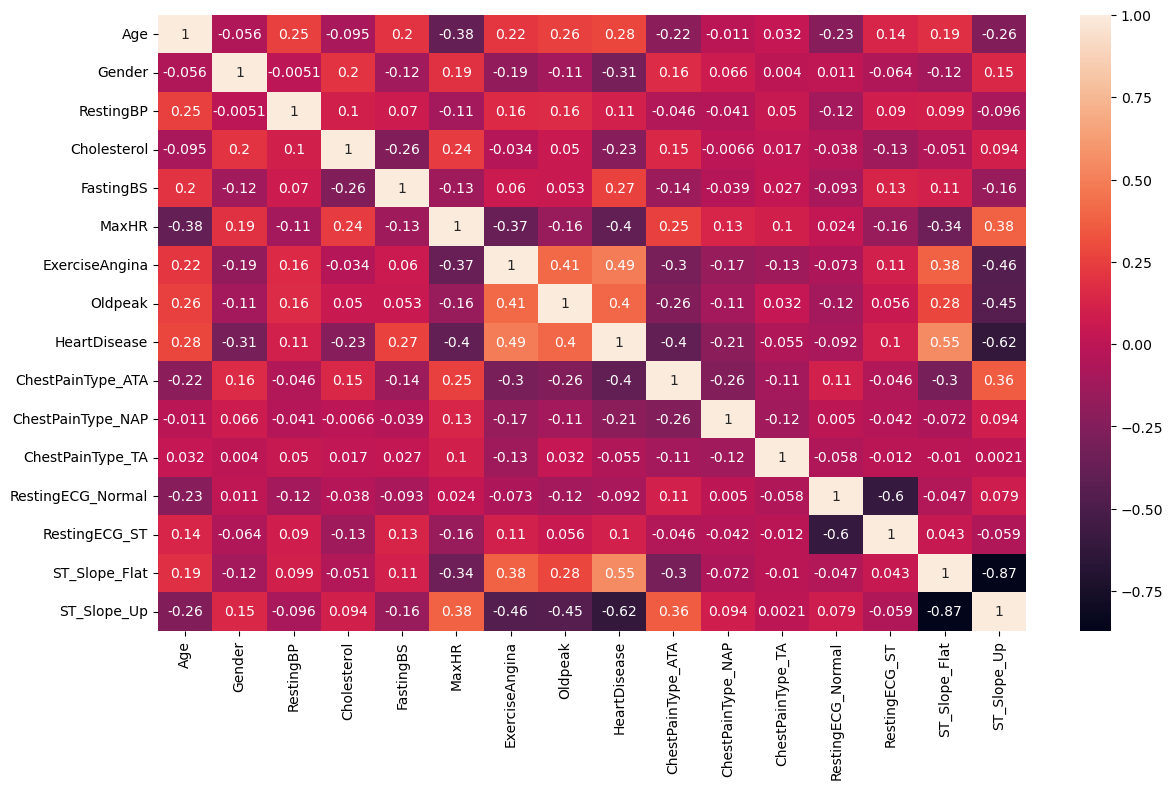

In [52]:
plt.figure(figsize = (14, 8))
sns.heatmap(
    corr, 
    annot = True
)
plt.show()

In [53]:
df_cleaned.dtypes

Age                    int64
Gender                 int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
ExerciseAngina         int64
Oldpeak              float64
HeartDisease           int64
ChestPainType_ATA      int64
ChestPainType_NAP      int64
ChestPainType_TA       int64
RestingECG_Normal      int64
RestingECG_ST          int64
ST_Slope_Flat          int64
ST_Slope_Up            int64
dtype: object

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
X = df_cleaned.drop("HeartDisease", axis = 1)

In [56]:
y = df_cleaned["HeartDisease"]

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [58]:
X_train.shape

(734, 15)

In [59]:
y_train.shape

(734,)

In [60]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [61]:
from sklearn.preprocessing import StandardScaler

In [62]:
scaler = StandardScaler()

In [63]:
X_train_scaled = scaler.fit_transform(X_train)

In [64]:
X_test_scaled = scaler.transform(X_test)

In [65]:
from sklearn.linear_model import LogisticRegression

In [68]:
model = LogisticRegression()

In [69]:
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [71]:
y_pred = model.predict(X_test_scaled)

In [72]:
comparison = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred
})

In [73]:
comparison

,Actual,Predicted
668,0,0
30,1,0
377,1,1
535,1,1
807,0,0
...,...,...
211,1,0
745,1,1
584,1,1
878,0,0


In [74]:
from sklearn.metrics import accuracy_score

In [76]:
accuracy_score(y_test, y_pred)*100

85.32608695652173

In [81]:
df.head()


,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [82]:
df_cleaned.head()

,Age,Gender,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0.0,0,1,0,0,1,0,0,1
1,49,1,160,180,0,156,0,1.0,1,0,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0.0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,1,1.5,1,0,0,0,1,0,1,0
4,54,0,150,195,0,122,0,0.0,0,0,1,0,1,0,0,1


In [83]:
df.shape

(918, 12)

In [85]:
df_cleaned.shape

(918, 16)